In [1]:
import pandas as pd
import numpy as np

pd.set_option("display.max_columns", 100)
pd.set_option("display.width", 160)

In [3]:
df = pd.read_csv("G6_retail_sales_dataset.csv")

In [4]:
df

,Transaction ID,Date,Customer ID,Gender,Age,Product Category,Quantity,Price per Unit,Total Amount
0,1,2023-11-24,CUST001,Male,34,Beauty,3,50,150
1,2,2023-02-27,CUST002,Female,26,Clothing,2,500,1000
2,3,2023-01-13,CUST003,Male,50,Electronics,1,30,30
3,4,2023-05-21,CUST004,Male,37,Clothing,1,500,500
4,5,2023-05-06,CUST005,Male,30,Beauty,2,50,100
...,...,...,...,...,...,...,...,...,...
995,996,2023-05-16,CUST996,Male,62,Clothing,1,50,50
996,997,2023-11-17,CUST997,Male,52,Beauty,3,30,90
997,998,2023-10-29,CUST998,Female,23,Beauty,4,25,100
998,999,2023-12-05,CUST999,Female,36,Electronics,3,50,150


In [5]:
df.columns

Index(['Transaction ID', 'Date', 'Customer ID', 'Gender', 'Age', 'Product Category', 'Quantity', 'Price per Unit', 'Total Amount'], dtype='str')

In [8]:
# Cehcking for any Missing or Extra columns
expected_cols = [
    "Transaction ID","Date","Customer ID","Gender","Age",
    "Product Category","Quantity","Price per Unit","Total Amount"
]
# Missing should be an empty set.
missing = set(expected_cols) - set(df.columns)
# If you have extra columns, that’s fine
extra = set(df.columns) - set(expected_cols)
print("Missing columns:", missing)
print("Unexpected columns:", extra)


Missing columns: set()
Unexpected columns: set()


In [9]:
# Parse types
df["Date"] = pd.to_datetime(df["Date"], errors="coerce")
df["Quantity"] = pd.to_numeric(df["Quantity"], errors="coerce")
df["Price per Unit"] = pd.to_numeric(df["Price per Unit"], errors="coerce")
df["Total Amount"] = pd.to_numeric(df["Total Amount"], errors="coerce")
df["Age"] = pd.to_numeric(df["Age"], errors="coerce")



In [10]:
# Standardize text columns
df["Product Category"] = df["Product Category"].astype(str).str.strip()
df["Gender"] = df["Gender"].astype(str).str.strip()

In [11]:
# Drop rows with invalid critical fields
before = len(df)
df = df.dropna(subset=["Date", "Quantity"])
after = len(df)
print(f"Dropped {before - after} rows with null Date/Quantity.")

Dropped 0 rows with null Date/Quantity.


In [12]:
# Recompute and compare to catch inconsistencies
re_total = df["Quantity"] * df["Price per Unit"]
inconsistent_mask = ~np.isclose(df["Total Amount"].fillna(re_total), re_total, equal_nan=True)

print("Inconsistent Total Amount rows:", int(inconsistent_mask.sum()))
# Normalize for downstream steps
df["Total Amount"] = re_total

Inconsistent Total Amount rows: 0


In [14]:
print("\n=== Shape ===")
print(df.shape)



=== Shape ===
(1000, 9)


In [15]:
print("\n=== Date Range ===")
print(df["Date"].min(), "→", df["Date"].max())



=== Date Range ===
2023-01-01 00:00:00 → 2024-01-01 00:00:00


In [16]:

print("\n=== Nulls by Column (Top 10) ===")
print(df.isna().sum().sort_values(ascending=False).head(10))



=== Nulls by Column (Top 10) ===
Transaction ID      0
Date                0
Customer ID         0
Gender              0
Age                 0
Product Category    0
Quantity            0
Price per Unit      0
Total Amount        0
dtype: int64


In [17]:

print("\n=== Basic Stats (Quantity / Price / Total) ===")
print(df[["Quantity","Price per Unit","Total Amount"]].describe(percentiles=[0.01,0.05,0.5,0.95,0.99]))


=== Basic Stats (Quantity / Price / Total) ===
          Quantity  Price per Unit  Total Amount
count  1000.000000     1000.000000   1000.000000
mean      2.514000      179.890000    456.000000
std       1.132734      189.681356    559.997632
min       1.000000       25.000000     25.000000
1%        1.000000       25.000000     25.000000
5%        1.000000       25.000000     25.000000
50%       3.000000       50.000000    135.000000
95%       4.000000      500.000000   1500.000000
99%       4.000000      500.000000   2000.000000
max       4.000000      500.000000   2000.000000


In [18]:

# Potential duplicates (depends on business logic)
dup_cols = ["Transaction ID"]  # or ["Date","Customer ID","Product Category"] if that defines uniqueness
dups = df.duplicated(subset=dup_cols, keep=False).sum()
print("Duplicate rows by Transaction ID:", int(dups))


Duplicate rows by Transaction ID: 0


In [19]:
# Simple outlier flags (we'll refine later if needed)
q_hi = df["Quantity"].quantile(0.99)
p_hi = df["Price per Unit"].quantile(0.99)
print(f"99th percentile Quantity: {q_hi:.2f}, Price per Unit: {p_hi:.2f}")
print("Extreme Quantity rows (> 99th pct):", int((df["Quantity"] > q_hi).sum()))
print("Extreme Price rows (> 99th pct):", int((df["Price per Unit"] > p_hi).sum()))


99th percentile Quantity: 4.00, Price per Unit: 500.00
Extreme Quantity rows (> 99th pct): 0
Extreme Price rows (> 99th pct): 0


In [20]:
print("\n=== Category distribution (top 15) ===")
print(df["Product Category"].value_counts().head(15))



=== Category distribution (top 15) ===
Product Category
Clothing       351
Electronics    342
Beauty         307
Name: count, dtype: int64


In [23]:
print("\n=== Gender distribution ===")
print(df["Gender"].value_counts(dropna=False))



=== Gender distribution ===
Gender
Female    510
Male      490
Name: count, dtype: int64


In [24]:
# Daily counts (how many transactions per day)
daily_tx = df.groupby("Date").size().rename("transactions").reset_index()
print("\nDaily transaction count stats:")
print(daily_tx["transactions"].describe())



Daily transaction count stats:
count    345.000000
mean       2.898551
std        1.571410
min        1.000000
25%        2.000000
50%        3.000000
75%        4.000000
max       11.000000
Name: transactions, dtype: float64


In [27]:
# Daily demand series (sum Quantity per day)
daily_qty = df.groupby("Date", as_index=False)["Quantity"].sum().sort_values("Date")
print("\nDaily demand (first 5):")
print(daily_qty.head())


Daily demand (first 5):
        Date  Quantity
0 2023-01-01        10
1 2023-01-02        10
2 2023-01-03         2
3 2023-01-04         8
4 2023-01-05         5


In [26]:
print("\nDaily demand (last 5):")
print(daily_qty.tail())


Daily demand (last 5):
          Date  Quantity
340 2023-12-27         4
341 2023-12-28         7
342 2023-12-29        13
343 2023-12-31         2
344 2024-01-01         4


In [28]:

# 1. Daily demand (sum)
daily = df.groupby("Date", as_index=False)["Quantity"].sum().sort_values("Date").reset_index(drop=True)

print("Daily shape:", daily.shape)
print(daily.head())


Daily shape: (345, 2)
        Date  Quantity
0 2023-01-01        10
1 2023-01-02        10
2 2023-01-03         2
3 2023-01-04         8
4 2023-01-05         5


In [31]:
# 2. Add time index
daily["Day"] = np.arange(len(daily))

In [33]:
# 3. Add day-of-week seasonality
daily["dow"] = daily["Date"].dt.dayofweek   # 0=Mon, 6=Sun


In [34]:
# 4. Rolling averages (7 days) and shift by 1 to avoid leakage
daily["qty_ma7"] = daily["Quantity"].rolling(7, min_periods=1).mean().shift(1)
daily["qty_ma7"] = daily["qty_ma7"].fillna(daily["Quantity"].expanding().mean())

print("\nDaily with engineered features:")
print(daily.head(10))



Daily with engineered features:
        Date  Quantity  Day  dow    qty_ma7
0 2023-01-01        10    0    6  10.000000
1 2023-01-02        10    1    0  10.000000
2 2023-01-03         2    2    1  10.000000
3 2023-01-04         8    3    2   7.333333
4 2023-01-05         5    4    3   7.500000
5 2023-01-06         5    5    4   7.000000
6 2023-01-07         6    6    5   6.666667
7 2023-01-08         3    7    6   6.571429
8 2023-01-09         4    8    0   5.571429
9 2023-01-10         5    9    1   4.714286


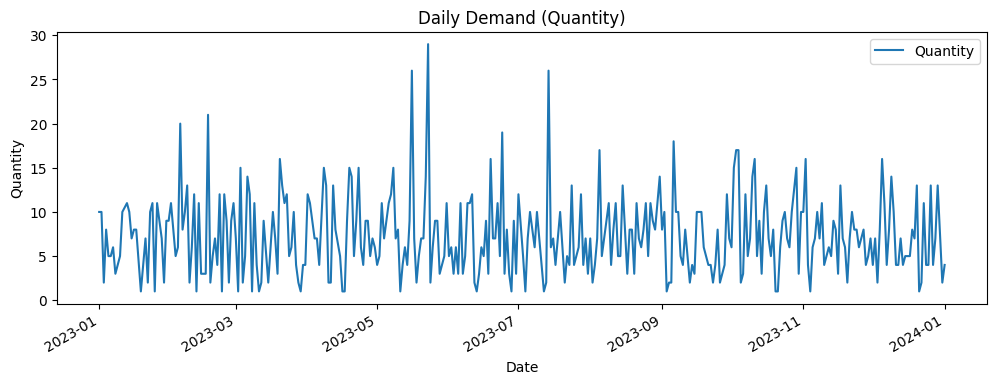

In [43]:
# 5. Plot daily demand
# daily.plot(x="Date", y="Quantity", figsize=(12,4))
import matplotlib.pyplot as plt
# plt.plot(daily["Date"], daily["Quantity"], figsize=(12,4))

daily.plot(x="Date", y="Quantity", figsize=(12,4))
plt.title("Daily Demand (Quantity)")
plt.xlabel("Date")
plt.ylabel("Quantity")
plt.show()


In [44]:
import pandas as pd
import numpy as np

# Ensure daily has needed columns (from Step 2)
assert {"Date", "Quantity", "Day", "dow", "qty_ma7"} <= set(daily.columns)

# One-hot for day-of-week (drop_first to avoid multicollinearity)
dow_dummies = pd.get_dummies(daily["dow"], prefix="dow", drop_first=True)

# Feature matrix
X = pd.concat([daily[["Day", "qty_ma7"]], dow_dummies], axis=1)
y = daily["Quantity"].astype(float)

feature_cols = X.columns.tolist()
print("Features:", feature_cols)
print("X shape:", X.shape, "| y shape:", y.shape)

Features: ['Day', 'qty_ma7', 'dow_1', 'dow_2', 'dow_3', 'dow_4', 'dow_5', 'dow_6']
X shape: (345, 8) | y shape: (345,)


In [45]:
split = int(len(X) * 0.8)
X_train, X_test = X.iloc[:split], X.iloc[split:]
y_train, y_test = y.iloc[:split], y.iloc[split:]
dates_train = daily["Date"].iloc[:split]
dates_test  = daily["Date"].iloc[split:]

print(f"Train periods: {len(X_train)}, Test periods: {len(X_test)}")
print("Train range:", dates_train.min(), "→", dates_train.max())
print("Test  range:", dates_test.min(),  "→", dates_test.max())

Train periods: 276, Test periods: 69
Train range: 2023-01-01 00:00:00 → 2023-10-21 00:00:00
Test  range: 2023-10-22 00:00:00 → 2024-01-01 00:00:00


In [48]:
from sklearn.linear_model import LinearRegression

model_lr = LinearRegression()
model_lr.fit(X_train, y_train)

y_pred = model_lr.predict(X_test)
print("Coefficients:")
for name, coef in zip(feature_cols, model_lr.coef_):
    print(f"  {name:>8}: {coef: .4f}")
print("\nIntercept:", model_lr.intercept_)

Coefficients:
       Day:  0.0005
   qty_ma7: -0.4054
     dow_1: -0.1996
     dow_2: -0.5214
     dow_3: -2.0819
     dow_4: -0.3978
     dow_5: -0.4400
     dow_6: -1.6958

Intercept: 11.017882720357115


In [49]:
from sklearn.metrics import mean_absolute_error, mean_squared_error
import numpy as np

mae  = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))

def smape(y_true, y_hat, eps=1e-8):
    # Symmetric MAPE is more stable at small quantities
    denom = (np.abs(y_true) + np.abs(y_hat) + eps) / 2.0
    return np.mean(np.abs(y_hat - y_true) / denom) * 100

mape = smape(y_test.values, y_pred)

print(f"MAE : {mae:.3f}")
print(f"RMSE: {rmse:.3f}")
print(f"sMAPE (%): {mape:.2f}")

MAE : 2.824
RMSE: 3.555
sMAPE (%): 41.92


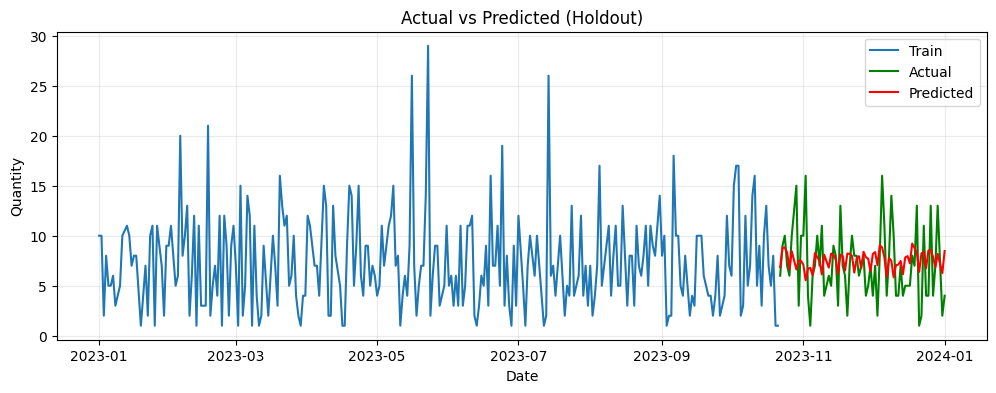

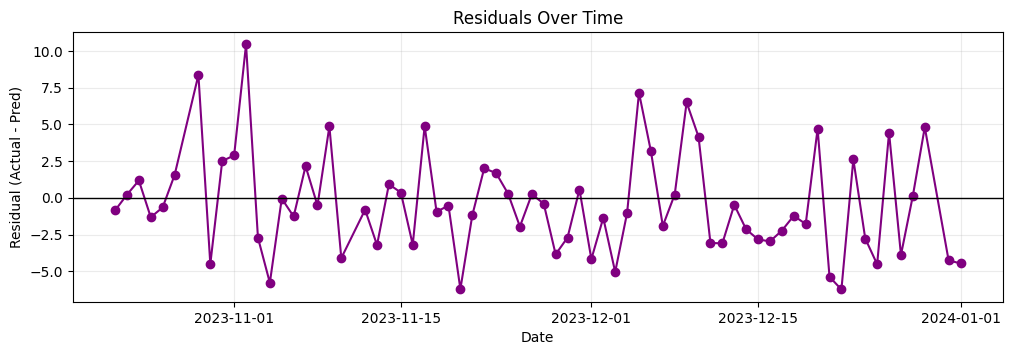

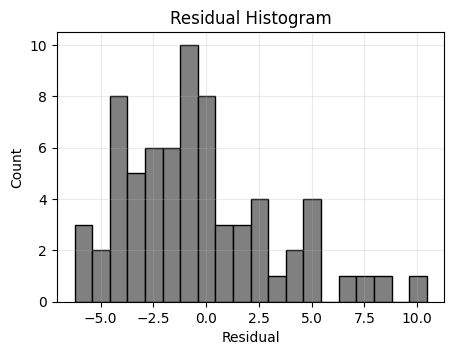

In [51]:
import matplotlib.pyplot as plt

# 1) Actual vs Predicted on the holdout
plt.figure(figsize=(12,4))
plt.plot(dates_train, y_train, label="Train", color="#1f77b4")
plt.plot(dates_test, y_test, label="Actual", color="green")
plt.plot(dates_test, y_pred, label="Predicted", color="red")
plt.title("Actual vs Predicted (Holdout)")
plt.xlabel("Date"); plt.ylabel("Quantity"); plt.legend(); plt.grid(alpha=0.25)
plt.show()

# 2) Residuals over time
resid = y_test.values - y_pred
plt.figure(figsize=(12,3.5))
plt.plot(dates_test, resid, marker="o", linestyle="-", color="purple")
plt.axhline(0, color="black", linewidth=1)
plt.title("Residuals Over Time")
plt.xlabel("Date"); plt.ylabel("Residual (Actual - Pred)")
plt.grid(alpha=0.25)
plt.show()

# 3) Residual distribution (quick sanity)
plt.figure(figsize=(5,3.5))
plt.hist(resid, bins=20, color="gray", edgecolor="black")
plt.title("Residual Histogram"); plt.xlabel("Residual"); plt.ylabel("Count")
plt.grid(alpha=0.25)
plt.show()

____

In [53]:
# Daily demand (sum) + median price
daily = (
    df.groupby("Date", as_index=False)
      .agg(Quantity=("Quantity", "sum"),
           MedianPrice=("Price per Unit", "median"))
      .sort_values("Date")
      .reset_index(drop=True)
)

# Time index & seasonality
daily["Day"] = np.arange(len(daily))
daily["dow"] = daily["Date"].dt.dayofweek  # 0=Mon, ..., 6=Sun

# Rolling features (shifted to avoid leakage)
daily["qty_ma7"]  = daily["Quantity"].rolling(7, min_periods=1).mean().shift(1)
daily["qty_std7"] = daily["Quantity"].rolling(7, min_periods=2).std().shift(1)

# Lags
daily["qty_lag1"] = daily["Quantity"].shift(1)
daily["qty_lag7"] = daily["Quantity"].shift(7)

# Fill initial NaNs with sensible backfills
daily["qty_ma7"]  = daily["qty_ma7"].fillna(daily["Quantity"].expanding().mean())
daily["qty_std7"] = daily["qty_std7"].fillna(0.0)
daily["qty_lag1"] = daily["qty_lag1"].fillna(daily["Quantity"].iloc[:3].mean())
daily["qty_lag7"] = daily["qty_lag7"].fillna(daily["Quantity"].iloc[:7].mean())

print("Top 10 rows of daily demand with features:")
print(daily.head(10))
print("Last 5 rows:")
print(daily.tail(5))

Top 10 rows of daily demand with features:
        Date  Quantity  MedianPrice  Day  dow    qty_ma7  qty_std7   qty_lag1   qty_lag7
0 2023-01-01        10        300.0    0    6  10.000000  0.000000   7.333333   6.571429
1 2023-01-02        10         40.0    1    0  10.000000  0.000000  10.000000   6.571429
2 2023-01-03         2        300.0    2    1  10.000000  0.000000  10.000000   6.571429
3 2023-01-04         8         50.0    3    2   7.333333  4.618802   2.000000   6.571429
4 2023-01-05         5         50.0    4    3   7.500000  3.785939   8.000000   6.571429
5 2023-01-06         5        265.0    5    4   7.000000  3.464102   5.000000   6.571429
6 2023-01-07         6         25.0    6    5   6.666667  3.204164   5.000000   6.571429
7 2023-01-08         3        162.5    7    6   6.571429  2.935821   6.000000  10.000000
8 2023-01-09         4         50.0    8    0   5.571429  2.760262   3.000000  10.000000
9 2023-01-10         5         40.0    9    1   4.714286  1.976047 

In [55]:
import pandas as pd
import numpy as np

# One-hot encode day-of-week
dow_dummies = pd.get_dummies(daily["dow"], prefix="dow", drop_first=True)

# Feature matrix (you can toggle features if you want to A/B test)
X = pd.concat(
    [
        daily[["Day", "MedianPrice", "qty_ma7", "qty_std7", "qty_lag1", "qty_lag7"]],
        dow_dummies
    ],
    axis=1
)
y = daily["Quantity"].astype(float)

feature_cols = X.columns.tolist()

# Chronological 80/20 split
split = int(len(X) * 0.8)
X_train, X_test = X.iloc[:split], X.iloc[split:]
y_train, y_test = y.iloc[:split], y.iloc[split:]
dates_train = daily["Date"].iloc[:split]
dates_test  = daily["Date"].iloc[split:]

print("Feature columns:", feature_cols)
print("Train/Test sizes:", X_train.shape, X_test.shape)
print("Train:", dates_train.min(), "→", dates_train.max())
print("Test :", dates_test.min(),  "→", dates_test.max())


Feature columns: ['Day', 'MedianPrice', 'qty_ma7', 'qty_std7', 'qty_lag1', 'qty_lag7', 'dow_1', 'dow_2', 'dow_3', 'dow_4', 'dow_5', 'dow_6']
Train/Test sizes: (276, 12) (69, 12)
Train: 2023-01-01 00:00:00 → 2023-10-21 00:00:00
Test : 2023-10-22 00:00:00 → 2024-01-01 00:00:00


In [58]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error
import numpy as np

lr = LinearRegression()
lr.fit(X_train, y_train)

y_pred = lr.predict(X_test)

mae  = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))

def smape(y_true, y_hat, eps=1e-8):
    denom = (np.abs(y_true) + np.abs(y_hat) + eps) / 2.0
    return np.mean(np.abs(y_hat - y_true) / denom) * 100

smape_val = smape(y_test.values, y_pred)

print(f"MAE  : {mae:.3f}")
print(f"RMSE : {rmse:.3f}")
print(f"sMAPE: {smape_val:.2f}%")

# Coefficients for a quick read
coef_series = pd.Series(lr.coef_, index=feature_cols).sort_values(ascending=False)
print("\nTop + and - coefficients:")
print(pd.concat([coef_series.head(8), coef_series.tail(8)]))
print("\nIntercept:", lr.intercept_)

MAE  : 2.717
RMSE : 3.447
sMAPE: 40.61%

Top + and - coefficients:
qty_std7       0.072217
qty_lag1       0.053402
Day            0.000170
qty_lag7      -0.001271
MedianPrice   -0.004201
dow_1         -0.308998
dow_5         -0.438682
dow_4         -0.471129
MedianPrice   -0.004201
dow_1         -0.308998
dow_5         -0.438682
dow_4         -0.471129
qty_ma7       -0.472044
dow_2         -0.674680
dow_6         -1.624384
dow_3         -2.252692
dtype: float64

Intercept: 11.568245191344019


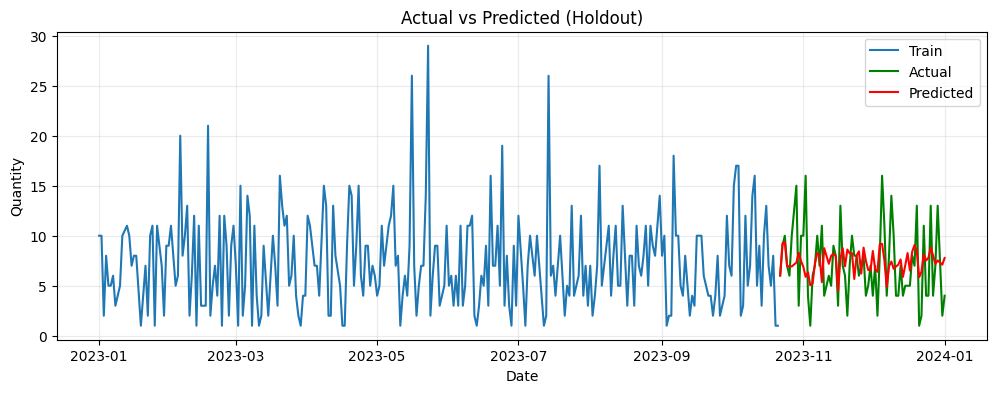

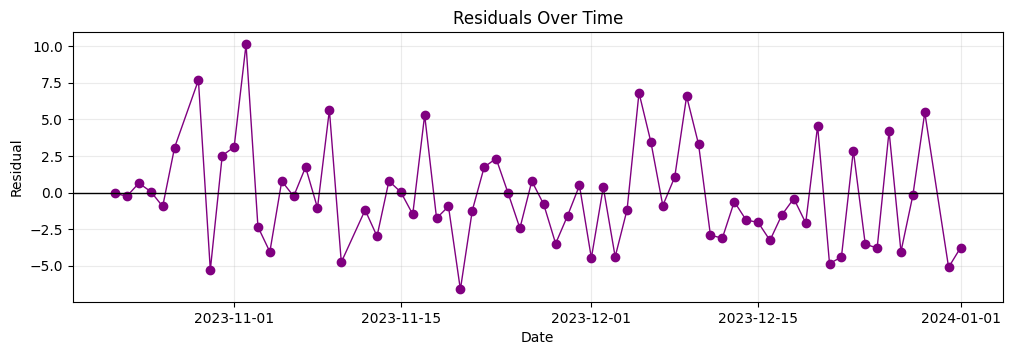

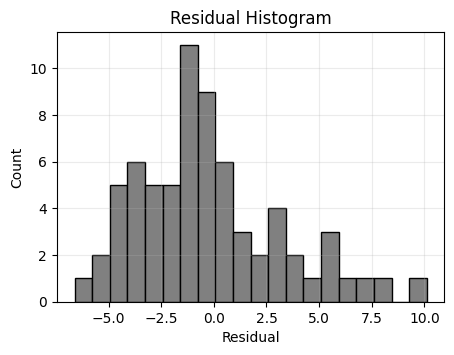

In [59]:
import matplotlib.pyplot as plt

# Actual vs Predicted
plt.figure(figsize=(12,4))
plt.plot(dates_train, y_train, label="Train", color="#1f77b4")
plt.plot(dates_test, y_test,  label="Actual", color="green")
plt.plot(dates_test, y_pred,  label="Predicted", color="red")
plt.title("Actual vs Predicted (Holdout)")
plt.xlabel("Date"); plt.ylabel("Quantity"); plt.legend(); plt.grid(alpha=0.25)
plt.show()

# Residuals
resid = y_test.values - y_pred
plt.figure(figsize=(12,3.5))
plt.plot(dates_test, resid, marker="o", linewidth=1, color="purple")
plt.axhline(0, color="black", linewidth=1)
plt.title("Residuals Over Time")
plt.xlabel("Date"); plt.ylabel("Residual")
plt.grid(alpha=0.25)
plt.show()

# Residual distribution
plt.figure(figsize=(5,3.5))
plt.hist(resid, bins=20, color="gray", edgecolor="black")
plt.title("Residual Histogram"); plt.xlabel("Residual"); plt.ylabel("Count")
plt.grid(alpha=0.25)
plt.show()